In [6]:
import os, sys
from ultralytics import SAM

In [11]:
os.listdir('chess-photos')

['photo_20251130_135227.jpg',
 'photo_20251130_135301.jpg',
 'photo_20251130_142008.jpg',
 'photo_20251130_142015.jpg',
 'photo_20251130_142019.jpg',
 'photo_20251130_142043.jpg',
 'photo_20251130_142057.jpg',
 'photo_20251130_142104.jpg',
 'photo_20251130_142157.jpg',
 'photo_20251130_142232.jpg',
 'photo_20251130_142310.jpg',
 'photo_20251130_142409.jpg',
 'photo_20251130_142420.jpg',
 'photo_20251130_142426.jpg',
 'photo_20251130_151308.jpg',
 'photo_20251130_151342.jpg',
 'photo_20251130_151355.jpg',
 'photo_20251130_153026.jpg',
 'photo_20251130_153035.jpg',
 'photo_20251130_153047.jpg',
 'photo_20251130_153115.jpg',
 'photo_20251130_153148.jpg',
 'photo_20251130_153155.jpg',
 'photo_20251130_153200.jpg',
 'photo_20251130_153223.jpg',
 'photo_20251130_153245.jpg',
 'photo_20251130_153259.jpg',
 'photo_20251130_153336.jpg',
 'photo_20251130_153341.jpg',
 'photo_20251130_153355.jpg',
 'photo_20251130_153406.jpg',
 'photo_20251130_153410.jpg',
 'photo_20251130_153422.jpg',
 'photo_20

In [4]:
from ultralytics import YOLO

# Load YOLO model
yolo_model = YOLO("best_yolo11.pt")

# Run inference on chess photo
results = yolo_model("chess-photos/photo_20251130_135227.jpg")

# Display results
results[0].show()
results[0].save("output_yolo_inference.jpg")


image 1/1 c:\Users\Gustavo\Desktop\dev\IA-FIC-IFSP\Aula_12\chess-photos\photo_20251130_135227.jpg: 384x640 2 black-kings, 2 black-knights, 2 black-pawns, 4 black-queens, 2 black-rooks, 6 white-kings, 3 white-knights, 2 white-pawns, 4 white-queens, 1 white-rook, 10.2ms
Speed: 2.2ms preprocess, 10.2ms inference, 20.8ms postprocess per image at shape (1, 3, 384, 640)


'output_yolo_inference.jpg'

# SAM2

In [7]:
# model = SAM("sam3.pt")
model = SAM("sam2.1_l.pt")

In [10]:
# Example 1: Interactive Point Prompts - Click to Segment
import matplotlib
matplotlib.use('TkAgg')  # Use TkAgg backend for separate window
import matplotlib.pyplot as plt
from PIL import Image

# Global variables to store clicked points
clicked_points = []
point_labels = []

def onclick(event):
    """Handle mouse clicks on the image"""
    if event.xdata is not None and event.ydata is not None:
        x, y = int(event.xdata), int(event.ydata)
        clicked_points.append([x, y])
        
        # Left click = foreground (1), Right click = background (0)
        if event.button == 1:  # Left click
            point_labels.append(1)
            color = 'lime'
            marker = 'o'
            label = 'Foreground'
        else:  # Right click
            point_labels.append(0)
            color = 'red'
            marker = 'x'
            label = 'Background'
        
        # Plot the point
        plt.plot(x, y, marker=marker, color=color, markersize=15, 
                markeredgewidth=3, markeredgecolor='white')
        plt.title(f'Click points on objects to segment\n'
                 f'Left click = Include | Right click = Exclude\n'
                 f'Close window when done ({len(clicked_points)} points selected)', 
                 fontsize=12)
        plt.draw()
        
        print(f"Point {len(clicked_points)}: ({x}, {y}) - {label}")

# Clear previous points
clicked_points = []
point_labels = []

# Load and display image for clicking
image_path = "chess-photos/photo_20251130_135227.jpg"
img = Image.open(image_path)

print("Opening image in separate window...")
print("Instructions:")
print("  - LEFT CLICK on object to include (foreground)")
print("  - RIGHT CLICK on area to exclude (background)")
print("  - CLOSE WINDOW when done selecting points")
print("")

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111)
ax.imshow(img)
ax.set_title('Click points on objects to segment\n'
            'Left click = Include | Right click = Exclude\n'
            'Close window when done', fontsize=12)
ax.axis('on')

# Connect click event
cid = fig.canvas.mpl_connect('button_press_event', onclick)

plt.show(block=True)  # Block until window is closed

# After closing the window, segment with the clicked points
print(f"\n{'='*60}")
if len(clicked_points) > 0:
    print(f"Segmenting with {len(clicked_points)} points...")
    print(f"Points: {clicked_points}")
    print(f"Labels: {point_labels}")
    print('='*60)
    
    # Run SAM2 segmentation
    results = model(
        image_path,
        points=[clicked_points],
        labels=[point_labels]
    )
    
    # Display results
    results[0].show()
    results[0].save("output_interactive_point_prompt.jpg")
    print("\n✅ Segmentation complete!")
    print(f"💾 Saved as: output_interactive_point_prompt.jpg")
    
    # Reset matplotlib backend
    matplotlib.use('inline')
else:
    print("⚠️ No points selected. Please run the cell again and click on the image.")
    matplotlib.use('inline')

Opening image in separate window...
Instructions:
  - LEFT CLICK on object to include (foreground)
  - RIGHT CLICK on area to exclude (background)
  - CLOSE WINDOW when done selecting points

Point 1: (3766, 1626) - Foreground
Point 2: (3651, 1890) - Foreground
Point 3: (3792, 1839) - Foreground
Point 4: (3588, 1788) - Foreground

Segmenting with 4 points...
Points: [[3766, 1626], [3651, 1890], [3792, 1839], [3588, 1788]]
Labels: [1, 1, 1, 1]

image 1/1 c:\Users\Gustavo\Desktop\chess-photos\photo_20251130_135227.jpg: 1024x1024 1 0, 279.5ms
Speed: 10.7ms preprocess, 279.5ms inference, 1.0ms postprocess per image at shape (1, 3, 1024, 1024)

✅ Segmentation complete!
💾 Saved as: output_interactive_point_prompt.jpg


In [11]:
# Example 2: Segmentation using Bounding Box
# Define box as [x1, y1, x2, y2] - top-left and bottom-right corners

results = model(
    "chess-photos/photo_20251130_135227.jpg",
    bboxes=[[100, 100, 300, 400]]  # Adjust coordinates to surround your target piece
)

results[0].show()
results[0].save("output_bbox_prompt.jpg")


image 1/1 c:\Users\Gustavo\Desktop\chess-photos\photo_20251130_135227.jpg: 1024x1024 1 0, 314.0ms
Speed: 9.2ms preprocess, 314.0ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)


'output_bbox_prompt.jpg'

In [12]:
# Example 2b: Interactive Bounding Box - Draw to Segment
import matplotlib
matplotlib.use('TkAgg')  # Use TkAgg backend for separate window
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# Global variables for bounding box
bbox_start = None
bbox_rect = None
bbox_list = []

def on_press(event):
    """Handle mouse press - start drawing box"""
    global bbox_start, bbox_rect
    if event.xdata is not None and event.ydata is not None:
        bbox_start = (int(event.xdata), int(event.ydata))
        print(f"Box start: {bbox_start}")

def on_release(event):
    """Handle mouse release - finish drawing box"""
    global bbox_start, bbox_rect, bbox_list
    if bbox_start is not None and event.xdata is not None and event.ydata is not None:
        x1, y1 = bbox_start
        x2, y2 = int(event.xdata), int(event.ydata)
        
        # Ensure x1 < x2 and y1 < y2
        x1, x2 = min(x1, x2), max(x1, x2)
        y1, y2 = min(y1, y2), max(y1, y2)
        
        bbox_list.append([x1, y1, x2, y2])
        
        # Draw the rectangle
        width = x2 - x1
        height = y2 - y1
        rect = Rectangle((x1, y1), width, height, 
                        fill=False, edgecolor='lime', linewidth=3)
        plt.gca().add_patch(rect)
        
        plt.title(f'Draw bounding boxes around objects\n'
                 f'Click and drag to draw | Close window when done\n'
                 f'{len(bbox_list)} box(es) drawn', fontsize=12)
        plt.draw()
        
        print(f"Box {len(bbox_list)}: [{x1}, {y1}, {x2}, {y2}]")
        bbox_start = None

def on_motion(event):
    """Handle mouse motion - show live rectangle while dragging"""
    global bbox_start, bbox_rect
    if bbox_start is not None and event.xdata is not None and event.ydata is not None:
        # Remove previous temporary rectangle
        if bbox_rect is not None:
            bbox_rect.remove()
        
        x1, y1 = bbox_start
        x2, y2 = int(event.xdata), int(event.ydata)
        
        width = x2 - x1
        height = y2 - y1
        
        # Draw temporary rectangle
        bbox_rect = Rectangle((x1, y1), width, height, 
                             fill=False, edgecolor='yellow', 
                             linewidth=2, linestyle='--')
        plt.gca().add_patch(bbox_rect)
        plt.draw()

# Clear previous boxes
bbox_list = []
bbox_start = None
bbox_rect = None

# Load and display image
image_path = "chess-photos/photo_20251130_135227.jpg"
img = Image.open(image_path)

print("Opening image in separate window...")
print("Instructions:")
print("  - CLICK and DRAG to draw bounding box around object")
print("  - You can draw MULTIPLE boxes")
print("  - CLOSE WINDOW when done drawing")
print("")

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111)
ax.imshow(img)
ax.set_title('Draw bounding boxes around objects\n'
            'Click and drag to draw | Close window when done\n'
            '0 box(es) drawn', fontsize=12)
ax.axis('on')

# Connect mouse events
fig.canvas.mpl_connect('button_press_event', on_press)
fig.canvas.mpl_connect('button_release_event', on_release)
fig.canvas.mpl_connect('motion_notify_event', on_motion)

plt.show(block=True)

# After closing the window, segment with the drawn boxes
print(f"\n{'='*60}")
if len(bbox_list) > 0:
    print(f"Segmenting with {len(bbox_list)} bounding box(es)...")
    print(f"Boxes: {bbox_list}")
    print('='*60)
    
    # Run SAM2 segmentation
    results = model(
        image_path,
        bboxes=bbox_list
    )
    
    # Display results
    results[0].show()
    results[0].save("output_interactive_bbox_prompt.jpg")
    print("\n✅ Segmentation complete!")
    print(f"💾 Saved as: output_interactive_bbox_prompt.jpg")
    
    # Reset matplotlib backend
    matplotlib.use('inline')
else:
    print("⚠️ No bounding boxes drawn. Please run the cell again and draw boxes.")
    matplotlib.use('inline')

Opening image in separate window...
Instructions:
  - CLICK and DRAG to draw bounding box around object
  - You can draw MULTIPLE boxes
  - CLOSE WINDOW when done drawing

Box start: (3520, 1537)
Box 1: [3520, 1537, 3520, 1537]
Box start: (3282, 955)
Box 2: [3282, 955, 3579, 1380]
Box start: (1422, 1040)
Box 3: [1422, 1040, 1740, 1401]
Box start: (1243, 361)
Box 4: [1243, 361, 1558, 828]

Segmenting with 4 bounding box(es)...
Boxes: [[3520, 1537, 3520, 1537], [3282, 955, 3579, 1380], [1422, 1040, 1740, 1401], [1243, 361, 1558, 828]]

image 1/1 c:\Users\Gustavo\Desktop\chess-photos\photo_20251130_135227.jpg: 1024x1024 1 1, 1 2, 1 3, 107.2ms
Speed: 102.8ms preprocess, 107.2ms inference, 10.9ms postprocess per image at shape (1, 3, 1024, 1024)

✅ Segmentation complete!
💾 Saved as: output_interactive_bbox_prompt.jpg


---

# SAM3 - Text Prompt Segmentation

SAM3 supports text prompts for segmentation!

## Step 1: Request Access to SAM3

1. Go to https://huggingface.co/facebook/sam3
2. Click "Agree and access repository" 
3. Accept Meta's license (approval is usually instant)

## Step 2: Get Your Hugging Face Token

1. Go to https://huggingface.co/settings/tokens
2. Create a new token (or use existing one)
3. Copy the token (starts with `hf_...`)

In [13]:
## Step 3: Login with Your Token

from huggingface_hub import login

# Login (will prompt for your token)
login()

# Or paste your token directly:
# login(token="hf_YOUR_TOKEN_HERE")

## Step 4: Load SAM3 Model

In [ ]:
from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

print("Loading SAM3 model...")
sam3_model = Sam3Model.from_pretrained("facebook/sam3").to(device)
sam3_processor = Sam3Processor.from_pretrained("facebook/sam3")
print("✅ SAM3 loaded successfully!")

c:\Users\Gustavo\miniconda3\envs\sam3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Loading SAM3 model...


Loading weights: 100%|██████████| 1468/1468 [00:01<00:00, 1034.63it/s, Materializing param=vision_encoder.neck.fpn_layers.3.proj2.weight]                       


✅ SAM3 loaded successfully!


In [2]:
## Example 1: Segment with Text Prompt

image_path = "chess-photos/photo_20251130_135227.jpg"
image = Image.open(image_path).convert("RGB")

# Use text prompt - THIS IS SAM3!
text_prompt = "chess piece" 

inputs = sam3_processor(images=image, text=text_prompt, return_tensors="pt").to(device)

print(f"Segmenting '{text_prompt}' with SAM3...")
with torch.no_grad():
    outputs = sam3_model(**inputs)

# Post-process
results = sam3_processor.post_process_instance_segmentation(
    outputs,
    threshold=0.5,
    mask_threshold=0.5,
    target_sizes=inputs.get("original_sizes").tolist()
)[0]

print(f"✅ Found {len(results['masks'])} objects matching '{text_prompt}'")
print(f"Confidence scores: {results['scores'].tolist()}")

Segmenting 'chess piece' with SAM3...
✅ Found 32 objects matching 'chess piece'
Confidence scores: [0.9556894302368164, 0.9432302117347717, 0.9457347393035889, 0.9652091264724731, 0.9383049011230469, 0.9568193554878235, 0.9449862241744995, 0.9384674429893494, 0.8721367120742798, 0.9279434680938721, 0.9350778460502625, 0.9580212235450745, 0.9576002955436707, 0.9650035500526428, 0.9110621213912964, 0.9528113603591919, 0.9579988121986389, 0.9448172450065613, 0.9559601545333862, 0.9271684885025024, 0.9388373494148254, 0.9297767281532288, 0.9372106194496155, 0.9375322461128235, 0.9315264821052551, 0.9242380261421204, 0.9502831697463989, 0.9556910991668701, 0.9414097666740417, 0.9494246244430542, 0.9443348050117493, 0.9571687579154968]


## Visualize SAM3 Results

In [14]:
def visualize_sam3(
    image,
    masks,
    boxes,
    scores,
    text_prompt: str,
    max_instances: int = 10,
    alpha: float = 0.6,
):
    """
    Visualiza resultados do SAM3 em Jupyter:
    - Todos os objetos em UMA imagem só.
    - Cada objeto com uma cor aleatória.
    - Limita para 'max_instances' para não travar.
    """

    # --- Garantir imagem como numpy HxWx3 ---
    if isinstance(image, torch.Tensor):
        img_np = image.detach().cpu().numpy()
        # Se vier como CxHxW, traz para HxWxC
        if img_np.ndim == 3 and img_np.shape[0] in (1, 3):
            img_np = np.moveaxis(img_np, 0, -1)
    else:
        # PIL.Image ou np.ndarray
        if hasattr(image, "convert"):  # PIL
            img_np = np.array(image.convert("RGB"))
        else:
            img_np = np.array(image)

    img_np = img_np.astype("float32")
    H, W = img_np.shape[:2]

    # --- Converter masks para numpy [N, H, W] bool ---
    if torch.is_tensor(masks):
        masks_np = masks.detach().cpu().numpy().astype(bool)
    else:
        masks_np = np.array(
            [m.detach().cpu().numpy().astype(bool) if torch.is_tensor(m) else m.astype(bool)
             for m in masks]
        )

    # --- Converter scores para numpy e ordenar por confiança ---
    if torch.is_tensor(scores):
        scores_np = scores.detach().cpu().numpy()
    else:
        scores_np = np.array(scores)

    num_instances = masks_np.shape[0]
    if num_instances == 0:
        print("Nenhuma máscara para visualizar.")
        return

    order = np.argsort(-scores_np)  # desc
    idxs = order[:min(max_instances, num_instances)]

    # --- Converter boxes, se forem tensores ---
    if torch.is_tensor(boxes):
        boxes_np = boxes.detach().cpu().numpy()
    else:
        boxes_np = np.array(
            [b.detach().cpu().numpy() if torch.is_tensor(b) else np.array(b)
             for b in boxes]
        )

    # --- Criar figura ---
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(img_np.astype("uint8"))

    # Overlay RGBA único
    overlay = np.zeros((H, W, 4), dtype="float32")

    rng = np.random.default_rng()

    for i, idx in enumerate(idxs):
        mask = masks_np[idx]
        if not mask.any():
            continue

        # Cor aleatória
        color_rgb = rng.random(3)  # [0,1] para R,G,B
        color_rgba = np.concatenate([color_rgb, [alpha]])

        # Aplica cor no overlay (onde mask == True)
        overlay[mask] = color_rgba

        # Caixa
        x1, y1, x2, y2 = boxes_np[idx].tolist()
        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor="yellow",
            linewidth=2,
        )
        # ax.add_patch(rect)

        # Label
        ax.text(
            x1,
            max(y1 - 5, 0),
            f"{text_prompt} {i+1}: {scores_np[idx]:.2f}",
            color="black",
            fontsize=10,
            bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.6),
        )

    # Desenhar overlay com alpha
    ax.imshow(overlay)

    ax.axis("off")
    ax.set_title(
        f"SAM3 Segmentation: '{text_prompt}' "
        f"(mostrando {len(idxs)}/{num_instances} instâncias)",
        fontsize=14,
    )
    plt.tight_layout()

    display(fig)
    plt.close(fig)

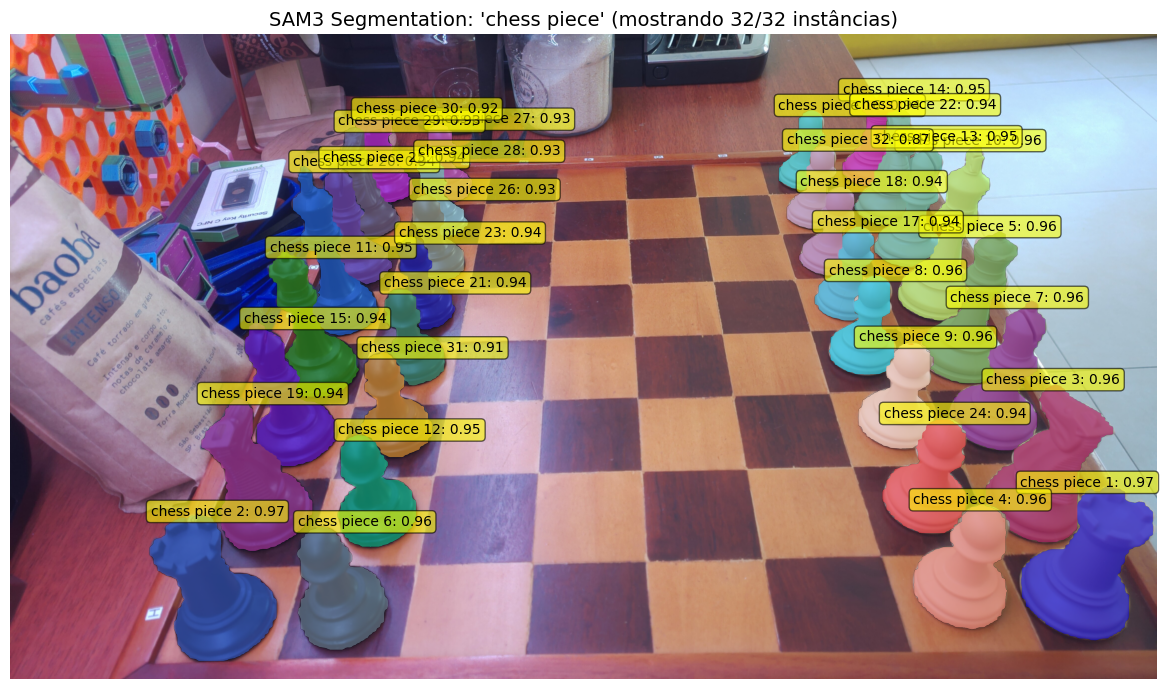

In [15]:
# Show results
if len(results['masks']) > 0:
    visualize_sam3(image, results['masks'], results['boxes'], 
                   results['scores'], text_prompt, max_instances=40, alpha=0.6)

## SAM3 Key Features

✅ **Text prompt support** - Segment objects using natural language  
✅ **Multiple instances** - Finds ALL matching objects in the image  
✅ **High accuracy** - 75-80% human performance on 270K concepts  
✅ **Open vocabulary** - Works with any object description  

### Comparison: SAM2 vs SAM3

| Feature | SAM2 | SAM3 |
|---------|------|------|
| Text prompts | ❌ No | ✅ Yes |
| Point prompts | ✅ Yes | ✅ Yes |
| Box prompts | ✅ Yes | ✅ Yes |
| Find all instances | Limited | ✅ Yes |
| Video support | ✅ Yes | ✅ Yes |